In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc, classification_report,
    silhouette_score
)
import joblib
import warnings
warnings.filterwarnings('ignore')
# Configuración de estilo para gráficas
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("✅ Todas las librerías importadas correctamente.")
print(f"  pandas      : {pd.__version__}")
print(f"  numpy       : {np.__version__}")
print(f"  matplotlib  : {plt.matplotlib.__version__}")
print(f"  seaborn     : {sns.__version__}")
print(f"  scikit-learn: {__import__('sklearn').__version__}")
print(f"  joblib      : {joblib.__version__}")

✅ Todas las librerías importadas correctamente.
  pandas      : 3.0.3
  numpy       : 2.4.6
  matplotlib  : 3.11.0
  seaborn     : 0.13.2
  scikit-learn: 1.9.0
  joblib      : 1.5.3


In [2]:
import os
BASE_PATH = r"c:\Users\santi\OneDrive\Desktop\9no Cuatri\Base de Datos\Conjunto de datos para 2a. evaluación-20260813"
# Verificación de que los archivos existen
archivos = ['beisbol.csv', 'breast-cancer.csv', 'samsung.csv', 'comprar_alquilar.csv']
for archivo in archivos:
    ruta = os.path.join(BASE_PATH, archivo)
    existe = "ENCONTRADO" if os.path.exists(ruta) else "NO ENCONTRADO"
    print(f"{existe} — {archivo}")

ENCONTRADO — beisbol.csv
ENCONTRADO — breast-cancer.csv
ENCONTRADO — samsung.csv
ENCONTRADO — comprar_alquilar.csv


In [3]:
# Carga de datos
ruta_beisbol = os.path.join(BASE_PATH, 'beisbol.csv')
df_beisbol = pd.read_csv(ruta_beisbol)

In [4]:
# Exploración inicial
print("--- Información del Dataset ---")
df_beisbol.info()
print("\n--- Estadísticas Descriptivas ---")
display(df_beisbol.describe())
print("\n--- Valores Nulos ---")
print(df_beisbol.isnull().sum())

--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  30 non-null     int64
 1   equipos     30 non-null     str  
 2   bateos      30 non-null     int64
 3   runs        30 non-null     int64
dtypes: int64(3), str(1)
memory usage: 1.1 KB

--- Estadísticas Descriptivas ---


,Unnamed: 0,bateos,runs
count,30.000000,30.000000,30.000000
mean,14.500000,5523.500000,693.600000
std,8.803408,79.873067,82.479088
min,0.000000,5417.000000,556.000000
25%,7.250000,5448.250000,629.000000
50%,14.500000,5515.500000,705.500000
75%,21.750000,5575.000000,734.000000
max,29.000000,5710.000000,875.000000



--- Valores Nulos ---
Unnamed: 0    0
equipos       0
bateos        0
runs          0
dtype: int64


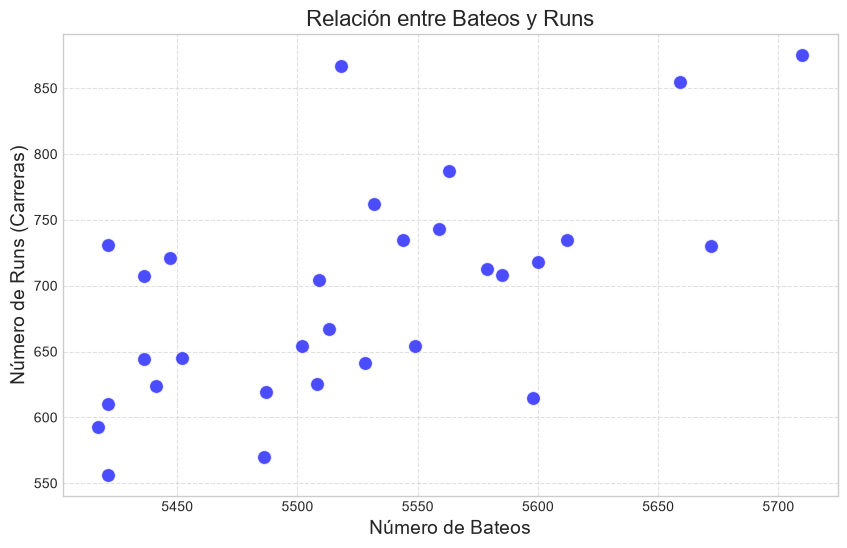

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bateos', y='runs', data=df_beisbol, color='blue', s=100, alpha=0.7)
plt.title('Relación entre Bateos y Runs', fontsize=16)
plt.xlabel('Número de Bateos', fontsize=14)
plt.ylabel('Número de Runs (Carreras)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [6]:
# División en variables predictoras (X) y objetivo (y)
X = df_beisbol[['bateos']] # Predictor: bateos
y = df_beisbol['runs']     # Objetivo: runs

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tamaño conjunto de entrenamiento: {len(X_train)} filas")
print(f"Tamaño conjunto de prueba: {len(X_test)} filas")

Tamaño conjunto de entrenamiento: 24 filas
Tamaño conjunto de prueba: 6 filas


In [8]:
# 1. Modelo Base: Regresión Lineal Simple
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [9]:
# 2. Optimización: Regresión Ridge (Buscando el mejor parámetro alpha)
ridge_model = Ridge()

In [10]:
# Definimos los hiperparámetros a probar (alpha controla la regularización)
parametros = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

In [11]:
grid_search = GridSearchCV(estimator=ridge_model, param_grid=parametros,
                           scoring='neg_mean_squared_error', cv=5)

In [12]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highe

In [13]:
best_ridge = grid_search.best_estimator_
ridge_pred = best_ridge.predict(X_test)
print(f"Mejor valor de alpha encontrado para Ridge: {grid_search.best_params_['alpha']}")

Mejor valor de alpha encontrado para Ridge: 100.0


In [16]:
# Función para calcular e imprimir métricas
def evaluar_modelo(y_real, y_pred, nombre_modelo):
    r2 = r2_score(y_real, y_pred)
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    print(f"--- Métricas para {nombre_modelo} ---")
    print(f"R² (Coef. de Determinación): {r2:.4f}")
    print(f"MAE (Error Absoluto Medio): {mae:.4f}")
    print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.4f}\n")
    return r2, mae, rmse
print("Evaluación en conjunto de prueba:")
evaluar_modelo(y_test, lr_pred, "Regresión Lineal Simple")
evaluar_modelo(y_test, ridge_pred, "Regresión Ridge (Optimizada)")

Evaluación en conjunto de prueba:
--- Métricas para Regresión Lineal Simple ---
R² (Coef. de Determinación): -0.5175
MAE (Error Absoluto Medio): 51.6116
RMSE (Raíz del Error Cuadrático Medio): 72.2494

--- Métricas para Regresión Ridge (Optimizada) ---
R² (Coef. de Determinación): -0.5172
MAE (Error Absoluto Medio): 51.6105
RMSE (Raíz del Error Cuadrático Medio): 72.2430



(-0.5172169631943799, 51.61050826692698, np.float64(72.24304654239113))

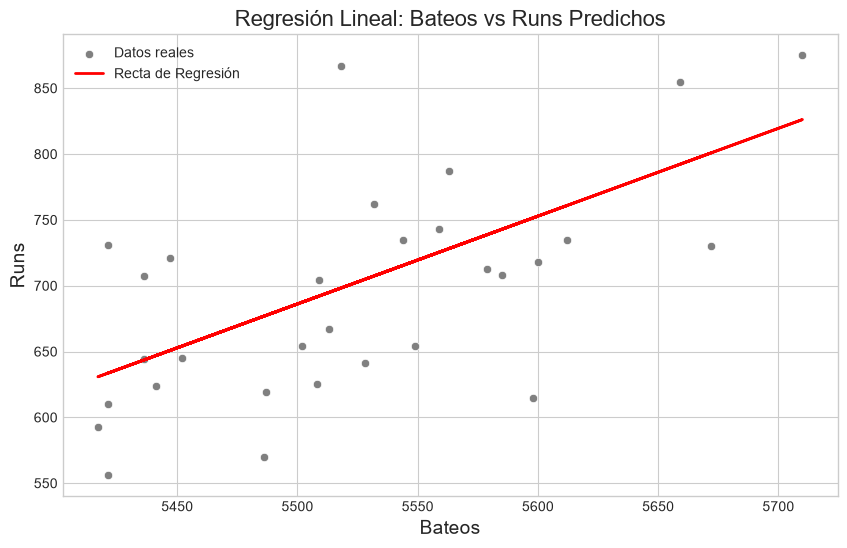

In [17]:
# Gráfica de la recta de regresión lineal sobre todos los datos
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bateos', y='runs', data=df_beisbol, color='gray', label='Datos reales')
# Creamos una línea con las predicciones del modelo lineal sobre todo el dataset
y_pred_total = lr_model.predict(X)
plt.plot(df_beisbol['bateos'], y_pred_total, color='red', linewidth=2, label='Recta de Regresión')
plt.title('Regresión Lineal: Bateos vs Runs Predichos', fontsize=16)
plt.xlabel('Bateos', fontsize=14)
plt.ylabel('Runs', fontsize=14)
plt.legend()
plt.show()

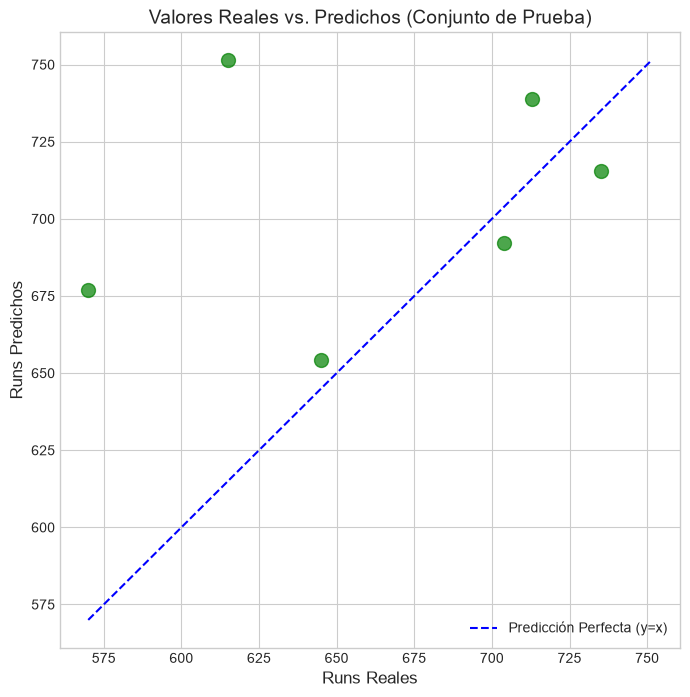

In [18]:
# Gráfica de Reales vs Predichos (solo en Test)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, lr_pred, color='green', alpha=0.7, s=100)
# Línea ideal y=x
p1 = max(max(y_test), max(lr_pred))
p2 = min(min(y_test), min(lr_pred))
plt.plot([p2, p1], [p2, p1], 'b--', label='Predicción Perfecta (y=x)')
plt.title('Valores Reales vs. Predichos (Conjunto de Prueba)', fontsize=14)
plt.xlabel('Runs Reales', fontsize=12)
plt.ylabel('Runs Predichos', fontsize=12)
plt.legend()
plt.show()

In [19]:
# Guardamos el modelo de Regresión Lineal
modelo_filename = 'modelo_beisbol_lr.pkl'
joblib.dump(lr_model, modelo_filename)
print(f"✅ Modelo guardado exitosamente como '{modelo_filename}'")

✅ Modelo guardado exitosamente como 'modelo_beisbol_lr.pkl'
